Deep learning has revolutionized the field of image classification, and one of the simplest yet powerful datasets used for benchmarking models is the MNIST dataset. The MNIST dataset consists of grayscale images of handwritten digits from 0 to 9, with each image being 28x28 pixels. This dataset is widely used for training image processing systems and testing classification algorithms.

In this chapter, we will focus on building a simple yet effective fully connected (linear) neural network using PyTorch to classify handwritten digits. Unlike convolutional neural networks (CNNs), which are commonly used for image classification, we will use a single-layer perceptron model to understand how a linear layer can perform classification tasks. We will also explore the use of GPU acceleration to improve computational efficiency.

In [1]:
import torch
import torchvision
import torch.nn as nn
from torchvision.transforms import ToTensor
import torch.nn.functional as F
import numpy as np
from torchvision.datasets import MNIST
from torch.utils.data import random_split
from torch.utils.data.dataloader import DataLoader
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
dataset = MNIST(root='data/', download = True, train=True, transform= ToTensor())

In [3]:
len(dataset)

60000

In [4]:
test_dataset = MNIST(root='data/', train=False, transform = ToTensor())
len(test_dataset)

10000

image.shape: torch.Size([1, 28, 28])
Label: 5


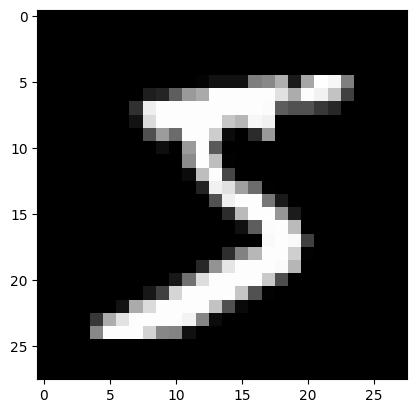

In [5]:
image, label = dataset[0]
print('image.shape:', image.shape)
plt.imshow(image[0], cmap='gray')
print('Label:', label)
plt.show()

image.shape: torch.Size([1, 28, 28])
Label: 5


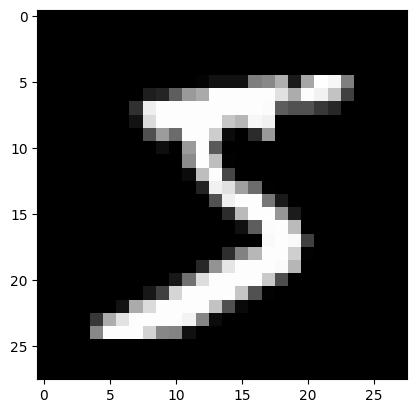

In [6]:
image, label = dataset[0]
print('image.shape:', image.shape)
plt.imshow(image.squeeze(), cmap='gray')
print('Label:', label)
plt.show()

In [7]:
plt.imshow(image[0], cmap='gray')

In [8]:
image[0]

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

In [9]:
val_size = 10000
train_size = len(dataset) - val_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])
len(train_ds), len(val_ds)

(50000, 10000)

In [10]:
batch_size = 128

train_loader = DataLoader(train_ds, batch_size, shuffle=True, num_workers=4, pin_memory=True)

val_loader = DataLoader(val_ds, batch_size*2, num_workers=4, pin_memory=True)

# purpose of num_workers pin_memory

images.shape: torch.Size([128, 1, 28, 28])


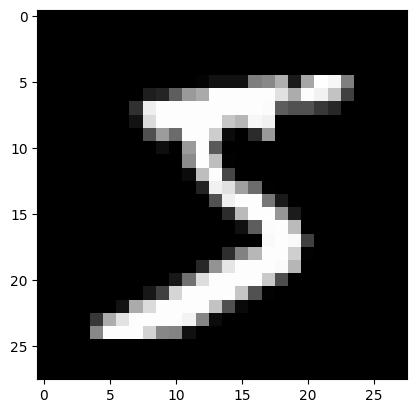

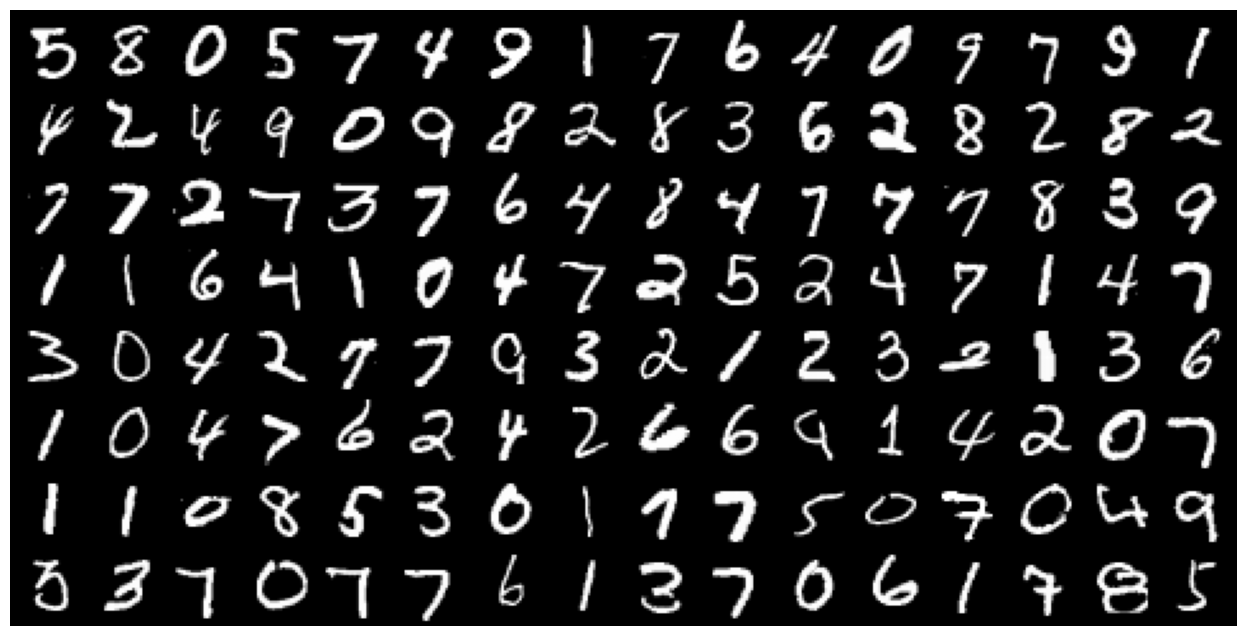

In [11]:
for images, _ in train_loader:
    print('images.shape:', images.shape)
    plt.figure(figsize=(16,8))
    plt.axis('off')
    plt.imshow(make_grid(images, nrow=16).permute((1, 2, 0)))
    plt.show()
    break



In [12]:
for images, labels in train_loader:
    print('images.shape', images.shape)
    inputs = images.reshape(-1, 784)
    print('inputs.shape:', inputs.shape)
    break



images.shape torch.Size([128, 1, 28, 28])
inputs.shape: torch.Size([128, 784])


In [13]:
input_size = inputs.shape[-1]
hidden_size = 32

layer1 = nn.Linear(input_size, hidden_size)

inputs.shape

torch.Size([128, 784])

In [14]:
layer1_outputs = layer1(inputs)
print('layer1_outputs.shape:', layer1_outputs.shape)

layer1_outputs.shape: torch.Size([128, 32])


__The image vectors of size 784 are transformed into intermediate output vectors of length 32 by performing a matrix multiplication of inputs matrix with the transposed weights matrix of layer1 and adding the bias. We can verify this using torch.allclose.__



In [15]:
torch.allclose(layer1_outputs, inputs)

RuntimeError: The size of tensor a (32) must match the size of tensor b (784) at non-singleton dimension 1

# Understanding Linear Layer Transformation and `torch.allclose`

## 1. Problem Context

We are working with flattened image vectors of size **784** (e.g., 28×28 images).
These inputs are passed through a **Linear (Fully Connected) layer** that transforms them into **32-dimensional feature vectors**.

```python
layer1 = nn.Linear(784, 32)
layer1_outputs = layer1(inputs)


In [20]:
manual_output = inputs @ layer1.weight.T + layer1.bias

In [21]:
torch.allclose(layer1_outputs, manual_output)

True

Input Image (28×28)

        ↓ 
        Flatten
   784-dimensional vector

        ↓ 
        Linear Layer
   32-dimensional feature vector


Thus, layer1_outputs and inputs have a linear relationship, i.e., each element of layer_outputs is a weighted sum of elements from inputs. Thus, even as we train the model and modify the weights, layer1 can only capture linear relationships between inputs and outputs
Next, we'll use the Rectified Linear Unit (ReLU) function as the activation function for the outputs. It has the formula relu(x) = max(0,x) i.e. it simply replaces negative values in a given tensor with the value 0. ReLU is a non-linear function, as seen here visually:



In [22]:
F.relu(torch.tensor([[1, -1, 0], [-0.1, .2, 3]]))

tensor([[1.0000, 0.0000, 0.0000],
        [0.0000, 0.2000, 3.0000]])

In [23]:
relu_outputs = F.relu(layer1_outputs)
print('min(layer1_outputs:)', torch.min(layer1_outputs).item())
print('min(relu_outputs):', torch.min(relu_outputs).item())

min(layer1_outputs:) -0.9972550868988037
min(relu_outputs): 0.0


In [24]:
relu_outputs

tensor([[0.0000, 0.0762, 0.0000,  ..., 0.3486, 0.1032, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.3057, 0.2570, 0.1138],
        [0.0000, 0.0000, 0.0882,  ..., 0.0000, 0.2735, 0.0578],
        ...,
        [0.0000, 0.1553, 0.0000,  ..., 0.2204, 0.0641, 0.0000],
        [0.1619, 0.0000, 0.0000,  ..., 0.0000, 0.1162, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.1590, 0.0771, 0.0000]],
       grad_fn=<ReluBackward0>)

In [25]:
output_size = 10
layer2 = nn.Linear(hidden_size, output_size)
layer2_outputs = layer2(relu_outputs)
print(layer2_outputs.shape)

torch.Size([128, 10])


In [26]:
inputs.shape

torch.Size([128, 784])

In [27]:
F.cross_entropy(layer2_outputs, labels)

tensor(2.3075, grad_fn=<NllLossBackward0>)

In [28]:
outputs =(F.relu(inputs @ layer1.weight.t() + layer1.bias)) @ layer2.weight.t() + layer2.bias

torch.allclose(outputs, layer2_outputs, 1e-3)

True

Note that outputs and inputs do not have a linear relationship due to the non-linear activation function F.relu. As we train the model and adjust the weights of layer1 and layer2, we can now capture non-linear relationships between the images and their labels. In other words, introducing non-linearity makes the model more powerful and versatile. Also, since hidden_size does not depend on the dimensions of the inputs or outputs, we vary it to increase the number of parameters within the model. We can also introduce new hidden layers and apply the same non-linear activation after each hidden layer.

The model we just created is called a neural network. A deep neural network is simply a neural network with one or more hidden layers. In fact, the Universal Approximation Theorem states that a sufficiently large & deep neural network can compute any arbitrary function i.e. it can learn rich and complex non-linear relationships between inputs and targets. Here are some examples:

Identifying if an image contains a cat or a dog (or something else)
Identifying the genre of a song using a 10-second sample
Classifying movie reviews as positive or negative based on their content
Navigating self-driving cars using a video feed of the road
Translating sentences from English to French (and hundreds of other languages)
Converting a speech recording to text and vice versa
And many more...
It's hard to imagine how the simple process of multiplying inputs with randomly initialized matrices, applying non-linear activations, and adjusting weights repeatedly using gradient descent can yield such astounding results. Deep learning models often contain millions of parameters, which can together capture far more complex relationships than the human brain can comprehend.

__If we hadn't included a non-linear activation between the two linear layers, the final relationship between inputs and outputs would still be linear. A simple refactoring of the computations illustrates this.__



In [29]:
# same as layer2(layer1(inputs))
outputs2 = (inputs @ layer1.weight.t() + layer1.bias) @ layer2.weight.t() + layer2.bias

In [30]:
#  Create a single layer to replace the two linear layers

combined_layer = nn.Linear(input_size, output_size)

combined_layer.weight.data = layer2.weight @ layer1.weight

combined_layer.bias.data = layer1.bias @ layer2.weight.t() + layer2.bias



In [31]:
outputs3 = inputs @ combined_layer.weight.t() + combined_layer.bias

torch.allclose(outputs2, outputs3, 1e-3)

True

We are now ready to define our model. As discussed above, we'll create a neural network with one hidden layer. Here's what that means:

Instead of using a single nn.Linear object to transform a batch of inputs (pixel intensities) into outputs (class probabilities), we'll use two nn.Linear objects. Each of these is called a layer in the network.

The first layer (also known as the hidden layer) will transform the input matrix of shape batch_size x 784 into an intermediate output matrix of shape batch_size x hidden_size. The parameter hidden_size can be configured manually (e.g., 32 or 64).

We'll then apply a non-linear activation function to the intermediate outputs. The activation function transforms individual elements of the matrix.

The result of the activation function, which is also of size batch_size x hidden_size, is passed into the second layer (also known as the output layer). The second layer transforms it into a matrix of size batch_size x 10. We can use this output to compute the loss and adjust weights using gradient descent.



In [32]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds== labels).item() / len(preds))

class MnistModel(nn.Module):
    """ Feed forward neural network with 1 hidden layer"""
    def __init__(self, in_size, hidden_size, out_size):
        super().__init__()
        # hidden layer
        self.linear1 = nn.Linear(in_size, hidden_size)
        # output layer
        self.linear2 = nn.Linear(hidden_size, out_size)

    def forward(self, xb):
        #Flatten the image tensors
        xb = xb.view(xb.size(0), -1)
        
        # Get intermediate outputs using hidden layer
        out = self.linear1(xb)
        
        # Apply activation function
        out = F.relu(out)

        # Get prediction using output layer
        out = self.linear2(out)
        return out

    def training_step(self, batch):
        images, labels = batch
        out = self(images) # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)       # Generate predictions
        loss = F.cross_entropy(out, labels) # calculate loss
        acc = accuracy(out, labels) # calculate accuracy
        return {'val_loss':loss, 'val_acc':acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean() # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean() # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, result['val_loss'], result['val_acc']))

    def evaluate(self, val_loader):
        """ Evaluate the model's performance on hte validation set"""
        outputs = [self.validation_step(batch) for batch in val_loader]
        return self.validation_epoch_end(outputs)

In [33]:
input_size = 784
hidden_size = 32
num_classes = 10

In [34]:
model = MnistModel(input_size, hidden_size=32, out_size=num_classes)

In [35]:
for t in model.parameters():
    print(t.shape)

torch.Size([32, 784])
torch.Size([32])
torch.Size([10, 32])
torch.Size([10])


In [36]:
model.parameters

<bound method Module.parameters of MnistModel(
  (linear1): Linear(in_features=784, out_features=32, bias=True)
  (linear2): Linear(in_features=32, out_features=10, bias=True)
)>

In [37]:
for images, labels in train_loader:
    outputs = model(images)
    loss = F.cross_entropy(outputs, labels)
    print('Loss:', loss.item())
    break

print('outputs.shape: ', outputs.shape)
print('Sample outputs: \n', outputs[:2].data)

Loss: 2.3256423473358154
outputs.shape:  torch.Size([128, 10])
Sample outputs: 
 tensor([[ 0.0248, -0.0602,  0.0699,  0.0838, -0.0717,  0.0531, -0.1111,  0.0426,
          0.0324,  0.1167],
        [ 0.1550, -0.1097,  0.0244,  0.0508, -0.0960,  0.1265, -0.1179,  0.0718,
         -0.0053,  0.1683]])


In [38]:
torch.cuda.is_available()

True

In [39]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

In [40]:
device = get_default_device()

In [41]:
device

device(type='cuda')

In [42]:
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)
    

The Python isinstance() function is a built-in method used to check if an object is an instance of a specified class or type, or any of its subclasses. It returns True or False (a boolean value). 

Syntax
The syntax for isinstance() is:
__isinstance(object, classinfo)__

object: The object or variable you want to check the type of.
classinfo: A class, type, or a tuple of classes and types to compare against. 

Key Features and Usage
Checks Inheritance: A key feature of isinstance() is that it considers inheritance. If an object is an instance of a subclass, isinstance() will return True for the parent class as well.

Multiple Type Checking: You can check an object against multiple types by providing a tuple of types to the classinfo parameter. 

In [43]:
for images, labels in train_loader:
    print(images.shape)
    images = to_device(images, device)
    print(images.device)
    break

torch.Size([128, 1, 28, 28])
cuda:0


__Finally, we define a DeviceDataLoader class to wrap our existing data loaders and move batches of data to the selected device. Interestingly, we don't need to extend an existing class to create a PyTorch datal oader. All we need is an __iter__ method to retrieve batches of data and an __len__ method to get the number of batches.__

In [44]:
class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

__The yield keyword in Python is used to create a generator function that can be used within a for loop, as illustrated below.__

In [45]:
def some_numbers():
    yield 10
    yield 20
    yield 30

for value in some_numbers():
    print(value)

10
20
30


In [46]:
for i in some_numbers():
    print(i)

10
20
30


In [47]:
train_loader = DeviceDataLoader(train_loader, device)
val_loader = DeviceDataLoader(val_loader, device)

In [48]:
for xb, yb in val_loader:
    print('xb.device:', xb.device)
    print('yb:', yb)
    break

xb.device: cuda:0
yb: tensor([7, 8, 3, 8, 7, 2, 7, 1, 1, 0, 7, 1, 5, 6, 1, 0, 7, 0, 9, 2, 7, 3, 2, 4,
        9, 0, 1, 6, 8, 6, 5, 9, 6, 5, 6, 9, 7, 3, 0, 6, 3, 0, 1, 5, 8, 4, 3, 8,
        5, 0, 1, 0, 8, 5, 1, 9, 3, 0, 4, 8, 3, 6, 1, 0, 7, 1, 4, 0, 9, 2, 2, 6,
        1, 6, 5, 1, 4, 5, 6, 3, 8, 0, 7, 2, 9, 0, 6, 4, 2, 7, 7, 5, 6, 9, 9, 9,
        5, 7, 7, 2, 9, 3, 7, 0, 8, 1, 0, 7, 3, 1, 7, 0, 7, 7, 6, 4, 7, 3, 1, 5,
        9, 5, 1, 4, 2, 6, 9, 9, 3, 8, 0, 7, 9, 0, 7, 3, 4, 9, 2, 1, 1, 3, 9, 7,
        8, 8, 1, 7, 4, 2, 6, 4, 9, 8, 9, 6, 7, 4, 3, 0, 6, 5, 3, 9, 3, 9, 1, 6,
        0, 2, 2, 8, 5, 7, 0, 0, 2, 6, 1, 8, 6, 0, 6, 7, 8, 5, 4, 7, 4, 3, 4, 5,
        7, 1, 0, 0, 4, 2, 6, 7, 6, 8, 5, 1, 1, 2, 7, 0, 3, 0, 0, 0, 2, 6, 4, 6,
        1, 6, 1, 4, 6, 9, 8, 3, 6, 4, 0, 7, 9, 4, 1, 8, 3, 2, 4, 9, 1, 4, 1, 5,
        8, 6, 7, 2, 8, 2, 3, 0, 4, 8, 2, 1, 1, 7, 9, 5], device='cuda:0')


# Training the model

In [51]:
def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    """Train the model using gradient descent"""
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        # Training Phase
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        # Validation phase
        result = model.evaluate(val_loader)
        model.epoch_end(epoch, result)
        history.append(result)
    return history

In [52]:
# model on gpu

model = MnistModel(input_size, hidden_size = hidden_size, out_size = num_classes)
to_device(model, device)

MnistModel(
  (linear1): Linear(in_features=784, out_features=32, bias=True)
  (linear2): Linear(in_features=32, out_features=10, bias=True)
)

In [53]:
history = [model.evaluate(val_loader)]
history

[{'val_loss': 2.3104727268218994, 'val_acc': 0.11113281548023224}]

In [54]:
history += fit(5, 0.5, model, train_loader, val_loader)
history

Epoch [0], val_loss: 0.2498, val_acc: 0.9231
Epoch [1], val_loss: 0.1791, val_acc: 0.9458
Epoch [2], val_loss: 0.1779, val_acc: 0.9487
Epoch [3], val_loss: 0.1515, val_acc: 0.9561
Epoch [4], val_loss: 0.1465, val_acc: 0.9566


[{'val_loss': 2.3104727268218994, 'val_acc': 0.11113281548023224},
 {'val_loss': 0.2497703582048416, 'val_acc': 0.923144519329071},
 {'val_loss': 0.17910674214363098, 'val_acc': 0.94580078125},
 {'val_loss': 0.17787235975265503, 'val_acc': 0.94873046875},
 {'val_loss': 0.15149453282356262, 'val_acc': 0.9560546875},
 {'val_loss': 0.14645950496196747, 'val_acc': 0.9566406011581421}]

In [55]:
history += fit(5, 0.1, model, train_loader, val_loader)
history

Epoch [0], val_loss: 0.1234, val_acc: 0.9634
Epoch [1], val_loss: 0.1235, val_acc: 0.9646
Epoch [2], val_loss: 0.1206, val_acc: 0.9644
Epoch [3], val_loss: 0.1217, val_acc: 0.9646
Epoch [4], val_loss: 0.1200, val_acc: 0.9648


[{'val_loss': 2.3104727268218994, 'val_acc': 0.11113281548023224},
 {'val_loss': 0.2497703582048416, 'val_acc': 0.923144519329071},
 {'val_loss': 0.17910674214363098, 'val_acc': 0.94580078125},
 {'val_loss': 0.17787235975265503, 'val_acc': 0.94873046875},
 {'val_loss': 0.15149453282356262, 'val_acc': 0.9560546875},
 {'val_loss': 0.14645950496196747, 'val_acc': 0.9566406011581421},
 {'val_loss': 0.12337648868560791, 'val_acc': 0.96337890625},
 {'val_loss': 0.12349764257669449, 'val_acc': 0.964550793170929},
 {'val_loss': 0.12064367532730103, 'val_acc': 0.96435546875},
 {'val_loss': 0.1216612383723259, 'val_acc': 0.964648425579071},
 {'val_loss': 0.1200248971581459, 'val_acc': 0.96484375}]

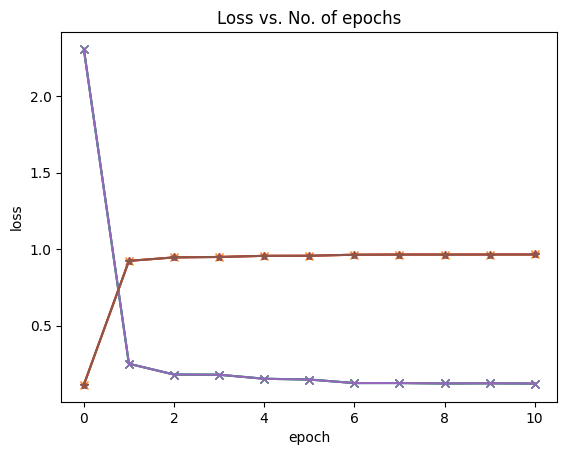

In [58]:
losses = [x['val_loss'] for x in history]
accuracies = [x['val_acc'] for x in history]
plt.plot(losses, '-x')
plt.plot(accuracies, '-*')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss vs. No. of epochs');
plt.show()

In [59]:
# define test dataset

test_dataset = MNIST(root='data/',
                    train=False,
                    transform=ToTensor())

In [60]:
def predict_image(img, model):
    xb = to_device(img.unsqueeze(0), device)
    yb = model(xb)
    _, preds = torch.max(yb, dim=1)
    return preds[0].item()

Label: 7 ,Predicted: 7


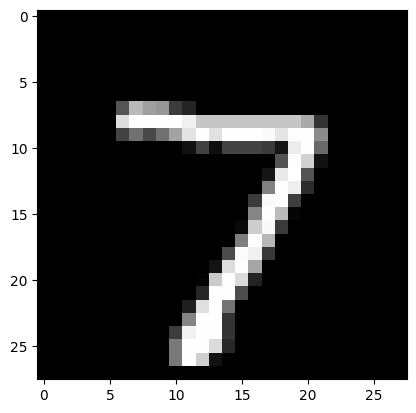

In [62]:
img, label = test_dataset[0]
plt.imshow(img[0], cmap='gray')
print('Label:', label, ',Predicted:', predict_image(img, model))
plt.show()

Label: 2 , Predicted: 2


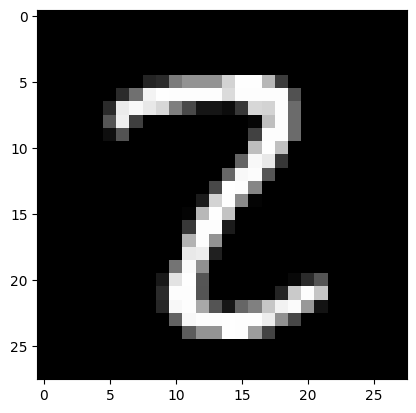

In [64]:
img, label = test_dataset[1839]
plt.imshow(img[0], cmap='gray')
print('Label:', label, ', Predicted:', predict_image(img, model))
plt.show()

Label: 9 , Predicted: 9


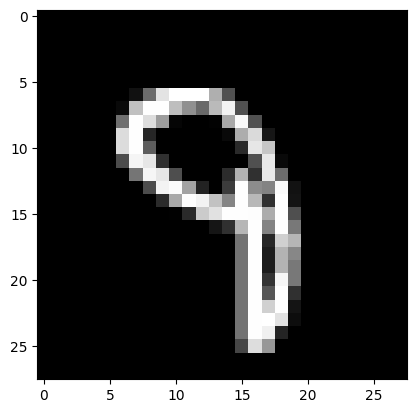

In [66]:
img, label = test_dataset[193]
plt.imshow(img[0], cmap='gray')
print('Label:', label, ', Predicted:', predict_image(img, model))
plt.show()

In [67]:
test_loader = DeviceDataLoader(DataLoader(test_dataset, batch_size=256), device)
result = model.evaluate(test_loader)
result

{'val_loss': 0.10538651794195175, 'val_acc': 0.9698241949081421}

In [68]:
torch.save(model.state_dict(), 'mnist-fnn.pth')

In [69]:
model2 = to_device(MnistModel(input_size, hidden_size, output_size), device)

model2.evaluate(test_loader)

{'val_loss': 2.3124005794525146, 'val_acc': 0.1103515625}

In [71]:
model2.load_state_dict(torch.load('mnist-fnn.pth'))
model2.state_dict()

C:\Users\Prasad\AppData\Local\Temp\ipykernel_1876\2536464075.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model2.load_state_dict(torch.load('mnist-fnn.pth'))


OrderedDict([('linear1.weight',
              tensor([[ 0.0183, -0.0065,  0.0003,  ..., -0.0042, -0.0317, -0.0200],
                      [-0.0061,  0.0290,  0.0064,  ...,  0.0031,  0.0300, -0.0283],
                      [ 0.0222,  0.0307,  0.0029,  ..., -0.0145,  0.0267,  0.0167],
                      ...,
                      [-0.0244,  0.0284, -0.0228,  ..., -0.0013, -0.0069,  0.0219],
                      [ 0.0089,  0.0058,  0.0065,  ...,  0.0195, -0.0172,  0.0268],
                      [ 0.0078,  0.0110, -0.0018,  ..., -0.0302,  0.0178, -0.0348]],
                     device='cuda:0')),
             ('linear1.bias',
              tensor([-0.0615,  0.4647,  0.4308,  0.2460,  0.1481, -0.0120,  0.1434,  0.0148,
                      -0.0677,  0.1975, -0.0195, -0.0388, -0.3194, -0.0256, -0.0245,  0.1894,
                       0.1489,  0.0332,  0.3898, -0.0583, -0.4713, -0.0770, -0.2197,  0.2040,
                       0.3261, -0.1791,  0.1329,  0.1419,  0.1206,  0.3773,  0.2198,

In [73]:
test_loader = DeviceDataLoader(DataLoader(test_dataset, batch_size=256), device)
result = model2.evaluate(test_loader)
result

{'val_loss': 0.10538651794195175, 'val_acc': 0.9698241949081421}